In [ ]:
pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.0 MB/s eta 0:00:00


In [ ]:
pip install gymnasium[box2d]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2409500 sha256=29392b6ccb130279ecd278b436ea55503c89be2dad9680df3a3555d010d3dcd0
  Stored in directory: /root/.cache/pip/wheels/2a/e9/60/774da0bcd07f7dc7761a8590fa2d065e4069568e78dcdc3318
Successfully built box2d-py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -----------------------
# Install dependencies
# -----------------------
!pip install --quiet gymnasium[box2d] torch torchvision matplotlib pandas pillow streamlit

# -----------------------
# Imports
# -----------------------
import os, random, time
from collections import deque, namedtuple
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

# -----------------------
# Config
# -----------------------
BASE_DIR = Path("/content/drive/MyDrive/lunar_lander_fullTraining")
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / "outputs"
MODELS_DIR = OUTPUT_DIR / "models"
LOGS_DIR   = OUTPUT_DIR / "logs"
PLOTS_DIR  = OUTPUT_DIR / "plots"
for d in (OUTPUT_DIR, MODELS_DIR, LOGS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

ENV_ID = "LunarLander-v3"
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -----------------------
# Training parameters
# -----------------------
QLEARNING_EPISODES = 20000
DQN_STEPS = 200_000
STM_DQN_STEPS = 250_000
EVAL_EPISODES = 50

DISCRETE_BINS = [10,10,10,10,6,6,4,4]
Transition = namedtuple('Transition', ('state','action','reward','next_state','done'))

BATCH_SIZE = 64
GAMMA = 0.99
LR = 1e-4
REPLAY_SIZE = 100_000
MIN_REPLAY_SIZE = 1000
TARGET_UPDATE_FREQ = 1000
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 150_000
SEQ_LEN = 8

# -----------------------
# Utilities
# -----------------------
def save_csv(df, path): df.to_csv(path, index=False)

def plot_rewards(rewards, title="Rewards", save_path=None, window=100):
    plt.figure(figsize=(10,5))
    plt.plot(rewards, label='Reward')
    if len(rewards) >= window:
        plt.plot(pd.Series(rewards).rolling(window).mean(), label=f'{window}-step mean')
    plt.xlabel('Episode'); plt.ylabel('Reward'); plt.title(title)
    plt.grid(True); plt.legend()
    if save_path: plt.savefig(save_path)
    plt.show()

# -----------------------
# Q-learning
# -----------------------
class Discretizer:
    def __init__(self, obs_space, bins):
        low, high = obs_space.low, obs_space.high
        self.low = np.where(np.isfinite(low), low, -1.)
        self.high = np.where(np.isfinite(high), high, 1.)
        self.bins = np.array(bins)
    def discretize(self, obs):
        r = (obs - self.low)/(self.high - self.low + 1e-8)
        r = np.clip(r, 0, 0.999999)
        return tuple((r*self.bins).astype(int))

def train_q_learning(env, episodes=QLEARNING_EPISODES, bins=DISCRETE_BINS):
    disc = Discretizer(env.observation_space, bins)
    act_n = env.action_space.n
    q = np.zeros(tuple(bins) + (act_n,))
    alpha = 0.1
    gamma = GAMMA
    eps, eps_end, decay = 1.0, 0.05, 0.995

    rewards = []
    step_logs = []  # Log per-step states, actions, rewards

    for ep in range(episodes):
        s,_ = env.reset(); s_d = disc.discretize(s)
        done = False
        ep_r = 0
        while not done:
            a = env.action_space.sample() if random.random() < eps else int(np.argmax(q[s_d]))
            ns,r,terminated,truncated,_ = env.step(a)
            done = terminated or truncated
            ns_d = disc.discretize(ns)

            # Update Q-table
            q[s_d+(a,)] += alpha*(r + gamma*np.max(q[ns_d])*(not done) - q[s_d+(a,)])

            # Log step
            step_logs.append({'episode': ep, 'state': s.tolist(), 'action': a, 'reward': r, 'next_state': ns.tolist(), 'done': done})

            s_d = ns_d
            s = ns
            ep_r += r
        rewards.append(ep_r)
        eps = max(eps_end, eps*decay)

        if (ep+1) % 500 == 0:
            print(f"Q-Learning {ep+1}/{episodes} → mean {np.mean(rewards[-500:]):.1f}")

    # Save Q-table, rewards, and step logs
    np.save(MODELS_DIR/'q_table.npy', q)
    pd.DataFrame({'episode':range(len(rewards)), 'reward':rewards}).to_csv(LOGS_DIR/'q_rewards.csv',index=False)
    pd.DataFrame(step_logs).to_csv(LOGS_DIR/'q_step_logs.csv',index=False)
    plot_rewards(rewards,"Q-learning Rewards",save_path=PLOTS_DIR/'q_learning_rewards.png')
    return q, rewards, step_logs

# -----------------------
# DQN / STM-DQN
# -----------------------
class ReplayBuffer:
    def __init__(self,cap): self.buf=deque(maxlen=cap)
    def push(self,*a): self.buf.append(Transition(*a))
    def sample(self,b): return Transition(*zip(*random.sample(self.buf,b)))
    def __len__(self): return len(self.buf)

class DQNNet(nn.Module):
    def __init__(self,obs,act):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs,256), nn.ReLU(),
                                 nn.Linear(256,256), nn.ReLU(),
                                 nn.Linear(256,act))
    def forward(self,x): return self.net(x)

class STM_DQNNet(nn.Module):
    def __init__(self,obs,act,h=128):
        super().__init__()
        self.lstm = nn.LSTM(obs,h,batch_first=True)
        self.fc = nn.Sequential(nn.Linear(h,128), nn.ReLU(), nn.Linear(128,act))
    def forward(self,x):
        if x.dim() == 2: x = x.unsqueeze(0)
        o,_ = self.lstm(x)
        return self.fc(o[:,-1,:])

def compute_eps(step):
    return EPS_END if step>=EPS_DECAY else EPS_START-(EPS_START-EPS_END)*(step/EPS_DECAY)

def train_dqn(env,total_steps,seq_model=False,model_name='dqn'):
    obs,act = env.observation_space.shape[0], env.action_space.n
    net = (STM_DQNNet if seq_model else DQNNet)(obs,act).to(DEVICE)
    tgt = (STM_DQNNet if seq_model else DQNNet)(obs,act).to(DEVICE)
    tgt.load_state_dict(net.state_dict())
    opt = optim.Adam(net.parameters(), lr=LR)
    buf = ReplayBuffer(REPLAY_SIZE)

    # Populate replay buffer
    s,_ = env.reset()
    while len(buf)<MIN_REPLAY_SIZE:
        a = env.action_space.sample()
        ns,r,terminated,truncated,_ = env.step(a)
        done = terminated or truncated
        buf.push(s,a,r,ns,done)
        s = ns if not done else env.reset()[0]

    s,_ = env.reset()
    seq = deque(maxlen=SEQ_LEN)
    for _ in range(SEQ_LEN-1): seq.append(np.zeros(obs))
    seq.append(s)
    rewards, losses = [], []
    step_logs = []
    steps, ep_r = 0, 0

    while steps<total_steps:
        eps = compute_eps(steps)
        if random.random()<eps:
            a = env.action_space.sample()
        else:
            if seq_model:
                inp = torch.tensor(np.array(seq)[None,:,:],dtype=torch.float32).to(DEVICE)
                a = int(net(inp).argmax(1).item())
            else:
                inp = torch.tensor(s[None,:],dtype=torch.float32).to(DEVICE)
                a = int(net(inp).argmax(1).item())

        ns,r,terminated,truncated,_ = env.step(a)
        done = terminated or truncated
        buf.push(s,a,r,ns,done)

        # Log step
        step_logs.append({'step': steps, 'state': s.tolist(), 'action': a, 'reward': r, 'next_state': ns.tolist(), 'done': done})

        s = ns; ep_r += r; steps += 1
        if seq_model: seq.append(ns)

        # Training step
        if len(buf) >= BATCH_SIZE:
            t = buf.sample(BATCH_SIZE)
            bs = np.stack(t.state)
            bn = np.stack(t.next_state)
            if seq_model:
                bs = np.repeat(bs[:,None,:],SEQ_LEN,axis=1)
                bn = np.repeat(bn[:,None,:],SEQ_LEN,axis=1)
            bs = torch.tensor(bs,dtype=torch.float32).to(DEVICE)
            bn = torch.tensor(bn,dtype=torch.float32).to(DEVICE)
            ba = torch.tensor(t.action).unsqueeze(1).to(DEVICE)
            br = torch.tensor(t.reward,dtype=torch.float32).to(DEVICE)
            bd = torch.tensor(t.done,dtype=torch.float32).to(DEVICE)
            qv = net(bs).gather(1,ba).squeeze(1)
            with torch.no_grad(): tq = br + GAMMA*tgt(bn).max(1)[0]*(1-bd)
            loss = nn.functional.mse_loss(qv,tq)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())

        if steps%TARGET_UPDATE_FREQ==0: tgt.load_state_dict(net.state_dict())
        if done:
            rewards.append(ep_r); ep_r=0
            s,_ = env.reset(); seq.clear()
            for _ in range(SEQ_LEN-1): seq.append(np.zeros(obs))
            seq.append(s)
        if steps%5000==0:
            print(f"{model_name}: step {steps}/{total_steps}, mean {np.mean(rewards[-100:]) if rewards else 0:.1f}")

    # Final save
    torch.save(net.state_dict(), MODELS_DIR/f"{model_name}.pth")
    pd.DataFrame({'step':range(len(rewards)), 'reward':rewards}).to_csv(LOGS_DIR/f"{model_name}_rewards.csv",index=False)
    pd.DataFrame(step_logs).to_csv(LOGS_DIR/f"{model_name}_step_logs.csv",index=False)
    plot_rewards(rewards,f"{model_name} Rewards", save_path=PLOTS_DIR/f"{model_name}_rewards.png")
    return MODELS_DIR/f"{model_name}.pth", rewards, losses, step_logs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 146.5 MB/s eta 0:00:00


Training Q-learning...
Q-Learning 500/20000 → mean -118.4
Q-Learning 1000/20000 → mean -122.2
Q-Learning 1500/20000 → mean -108.3
Q-Learning 2000/20000 → mean -109.6
Q-Learning 2500/20000 → mean -123.4
Q-Learning 3000/20000 → mean -121.4
Q-Learning 3500/20000 → mean -107.0
Q-Learning 4000/20000 → mean -114.4
Q-Learning 4500/20000 → mean -114.7
Q-Learning 5000/20000 → mean -108.2
Q-Learning 5500/20000 → mean -118.1
Q-Learning 6000/20000 → mean -110.6
Q-Learning 6500/20000 → mean -118.3
Q-Learning 7000/20000 → mean -109.6
Q-Learning 7500/20000 → mean -116.5
Q-Learning 8000/20000 → mean -104.9
Q-Learning 8500/20000 → mean -105.6
Q-Learning 9000/20000 → mean -112.9
Q-Learning 9500/20000 → mean -123.1
Q-Learning 10000/20000 → mean -109.9
Q-Learning 10500/20000 → mean -96.2
Q-Learning 11000/20000 → mean -118.3
Q-Learning 11500/20000 → mean -97.2
Q-Learning 12000/20000 → mean -107.7
Q-Learning 12500/20000 → mean -115.1
Q-Learning 13000/20000 → mean -120.0
Q-Learning 13500/20000 → mean -104.6


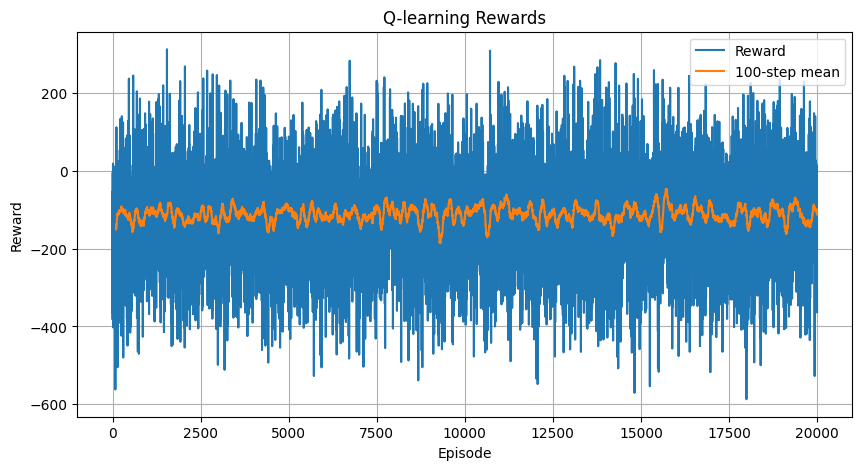

Q-learning → mean reward: -227.78, std: 141.70
Training DQN...
dqn: step 5000/200000, mean -186.7
dqn: step 10000/200000, mean -166.3
dqn: step 15000/200000, mean -143.2
dqn: step 20000/200000, mean -138.6
dqn: step 25000/200000, mean -119.5
dqn: step 30000/200000, mean -98.5
dqn: step 35000/200000, mean -88.5
dqn: step 40000/200000, mean -87.2
dqn: step 45000/200000, mean -91.1
dqn: step 50000/200000, mean -81.7
dqn: step 55000/200000, mean -66.3
dqn: step 60000/200000, mean -63.6
dqn: step 65000/200000, mean -66.6
dqn: step 70000/200000, mean -69.7
dqn: step 75000/200000, mean -69.5
dqn: step 80000/200000, mean -75.7
dqn: step 85000/200000, mean -69.6
dqn: step 90000/200000, mean -72.0
dqn: step 95000/200000, mean -76.7
dqn: step 100000/200000, mean -76.2
dqn: step 105000/200000, mean -74.1
dqn: step 110000/200000, mean -72.0
dqn: step 115000/200000, mean -71.9
dqn: step 120000/200000, mean -71.8
dqn: step 125000/200000, mean -68.7
dqn: step 130000/200000, mean -64.5
dqn: step 135000

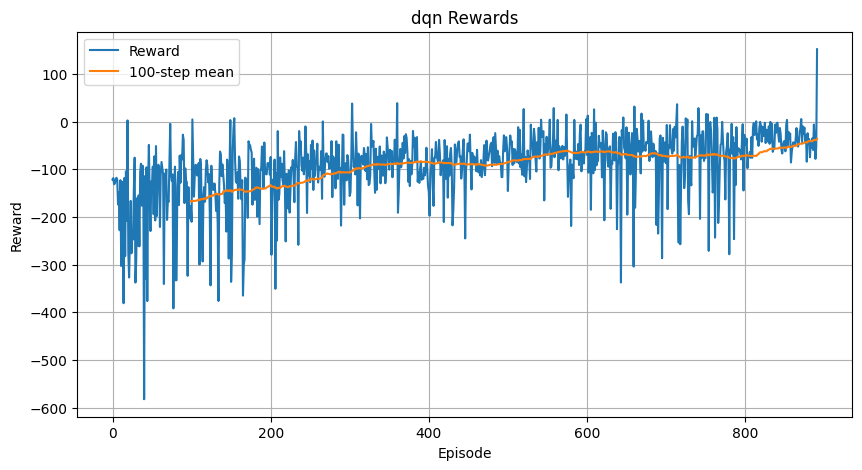

DQN → mean reward: -24.24, std: 48.35
Training STM-DQN...
stm_dqn: step 5000/250000, mean -196.0
stm_dqn: step 10000/250000, mean -178.3
stm_dqn: step 15000/250000, mean -149.4
stm_dqn: step 20000/250000, mean -127.4
stm_dqn: step 25000/250000, mean -112.5
stm_dqn: step 30000/250000, mean -106.1
stm_dqn: step 35000/250000, mean -99.2
stm_dqn: step 40000/250000, mean -95.2
stm_dqn: step 45000/250000, mean -86.4
stm_dqn: step 50000/250000, mean -84.2
stm_dqn: step 55000/250000, mean -78.8
stm_dqn: step 60000/250000, mean -70.4
stm_dqn: step 65000/250000, mean -73.7
stm_dqn: step 70000/250000, mean -68.8
stm_dqn: step 75000/250000, mean -56.0
stm_dqn: step 80000/250000, mean -54.2
stm_dqn: step 85000/250000, mean -57.9
stm_dqn: step 90000/250000, mean -54.1
stm_dqn: step 95000/250000, mean -52.4
stm_dqn: step 100000/250000, mean -48.9
stm_dqn: step 105000/250000, mean -39.8
stm_dqn: step 110000/250000, mean -29.2
stm_dqn: step 115000/250000, mean -13.8
stm_dqn: step 120000/250000, mean -3

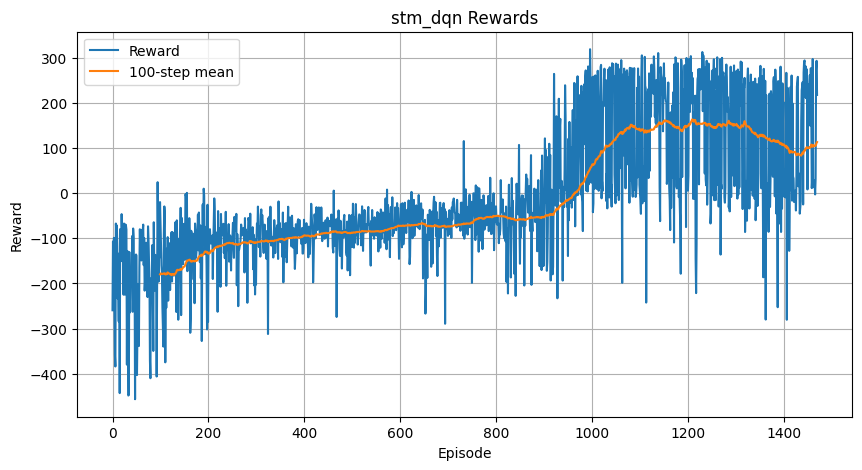

STM-DQN → mean reward: 181.80, std: 113.69


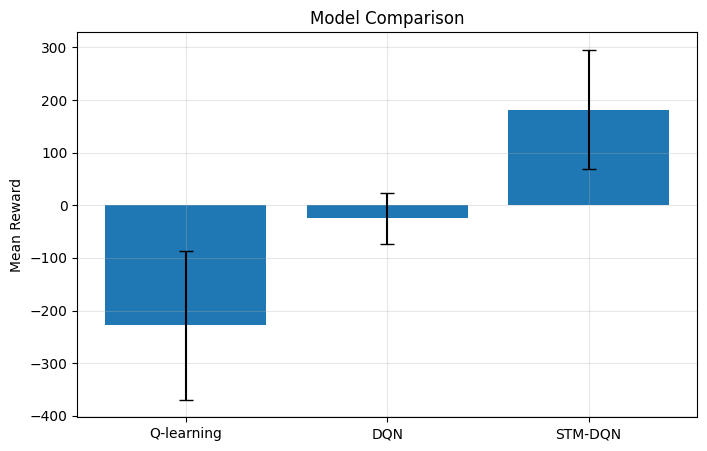

✅ Best Model: STM-DQN → /content/drive/MyDrive/lunar_lander_fullTraining/outputs/models/stm_dqn.pth


In [ ]:
# -----------------------
# Full training pipeline with step-wise logs
# -----------------------
# Evaluation functions
# -----------------------
def evaluate_q(q, env, ep=EVAL_EPISODES):
    disc = Discretizer(env.observation_space, DISCRETE_BINS)
    rewards = []
    for _ in range(ep):
        s,_ = env.reset()
        done = False
        ep_r = 0
        while not done:
            a = int(np.argmax(q[disc.discretize(s)]))
            ns,r,terminated,truncated,_ = env.step(a)
            done = terminated or truncated
            s = ns
            ep_r += r
        rewards.append(ep_r)
    return np.mean(rewards), np.std(rewards), rewards

def evaluate_torch(model_cls, path, env, seq=False):
    obs, act = env.observation_space.shape[0], env.action_space.n
    net = model_cls(obs, act).to(DEVICE)
    net.load_state_dict(torch.load(path, map_location=DEVICE))
    net.eval()

    rewards = []
    for _ in range(EVAL_EPISODES):
        s,_ = env.reset()
        done = False
        ep_r = 0
        seqb = deque(maxlen=SEQ_LEN)
        if seq:
            for _ in range(SEQ_LEN-1): seqb.append(np.zeros(obs))
            seqb.append(s)
        while not done:
            inp = torch.tensor(np.array(seqb)[None,:,:] if seq else s[None,:], dtype=torch.float32).to(DEVICE)
            a = int(net(inp).argmax(1).item())
            ns,r,terminated,truncated,_ = env.step(a)
            done = terminated or truncated
            s = ns
            ep_r += r
            if seq: seqb.append(s)
        rewards.append(ep_r)
    return np.mean(rewards), np.std(rewards), rewards

# -----------------------
def train_and_compare():
    env = gym.make(ENV_ID)

    # -------------------
    # Q-learning
    # -------------------
    q_table_path = MODELS_DIR/'q_table.npy'
    if q_table_path.exists():
        print("Loading existing Q-learning model...")
        q_table = np.load(q_table_path)
        q_rewards = pd.read_csv(LOGS_DIR/'q_rewards.csv')['reward'].tolist()
        q_step_logs = pd.read_csv(LOGS_DIR/'q_step_logs.csv').to_dict('records')
    else:
        print("Training Q-learning...")
        q_table, q_rewards, q_step_logs = train_q_learning(env)

    mq, sdq, _ = evaluate_q(q_table, env)
    print(f"Q-learning → mean reward: {mq:.2f}, std: {sdq:.2f}")

    # -------------------
    # DQN
    # -------------------
    dqn_path = MODELS_DIR/'dqn.pth'
    if dqn_path.exists():
        print("Loading existing DQN model...")
        dqn_rewards = pd.read_csv(LOGS_DIR/'dqn_rewards.csv')['reward'].tolist()
        dqn_step_logs = pd.read_csv(LOGS_DIR/'dqn_step_logs.csv').to_dict('records')
    else:
        print("Training DQN...")
        dqn_path, dqn_rewards, dqn_losses, dqn_step_logs = train_dqn(env, DQN_STEPS, seq_model=False, model_name='dqn')

    md, sd, _ = evaluate_torch(DQNNet, dqn_path, env)
    print(f"DQN → mean reward: {md:.2f}, std: {sd:.2f}")

    # -------------------
    # STM-DQN
    # -------------------
    stm_path = MODELS_DIR/'stm_dqn.pth'
    if stm_path.exists():
        print("Loading existing STM-DQN model...")
        stm_rewards = pd.read_csv(LOGS_DIR/'stm_dqn_rewards.csv')['reward'].tolist()
        stm_step_logs = pd.read_csv(LOGS_DIR/'stm_dqn_step_logs.csv').to_dict('records')
    else:
        print("Training STM-DQN...")
        stm_path, stm_rewards, stm_losses, stm_step_logs = train_dqn(env, STM_DQN_STEPS, seq_model=True, model_name='stm_dqn')

    ms, ss, _ = evaluate_torch(STM_DQNNet, stm_path, env, seq=True)
    print(f"STM-DQN → mean reward: {ms:.2f}, std: {ss:.2f}")

    # -------------------
    # Compare models
    # -------------------
    summary = pd.DataFrame([
        {'model':'Q-learning','mean':mq,'std':sdq,'file':str(q_table_path)},
        {'model':'DQN','mean':md,'std':sd,'file':str(dqn_path)},
        {'model':'STM-DQN','mean':ms,'std':ss,'file':str(stm_path)}
    ])
    save_csv(summary, OUTPUT_DIR/'model_comparison.csv')

    # Plot comparison
    plt.figure(figsize=(8,5))
    plt.bar(summary['model'], summary['mean'], yerr=summary['std'], capsize=5)
    plt.ylabel('Mean Reward'); plt.title('Model Comparison'); plt.grid(alpha=.3)
    plt.show()

    best = summary.loc[summary['mean'].idxmax()]
    print(f"✅ Best Model: {best['model']} → {best['file']}")

    return summary, best, {
        'q_step_logs': q_step_logs,
        'dqn_step_logs': dqn_step_logs,
        'stm_step_logs': stm_step_logs
    }

# -----------------------
# Run the pipeline
# -----------------------
summary, best_model, step_logs_dict = train_and_compare()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

LOGS_DIR = "/content/drive/MyDrive/lunar_lander_fullTraining/outputs/logs"
PLOTS_DIR = "/content/drive/MyDrive/lunar_lander_fullTraining/outputs/plots"

In [ ]:
def plot_reward_curve(filename, title):
    df = pd.read_csv(f"{LOGS_DIR}/{filename}")
    rewards = df['reward'].tolist()

    plt.figure(figsize=(10,5))
    plt.plot(rewards, label="Reward")
    if len(rewards) > 100:
        plt.plot(pd.Series(rewards).rolling(100).mean(), label="100-episode MA")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

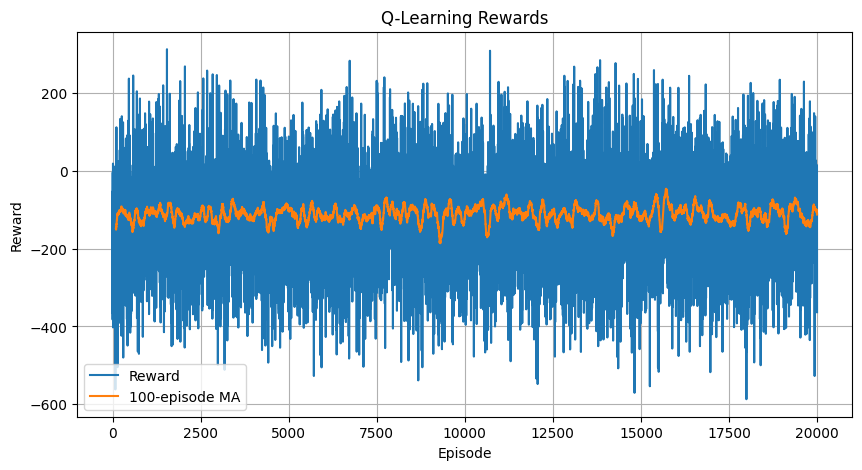

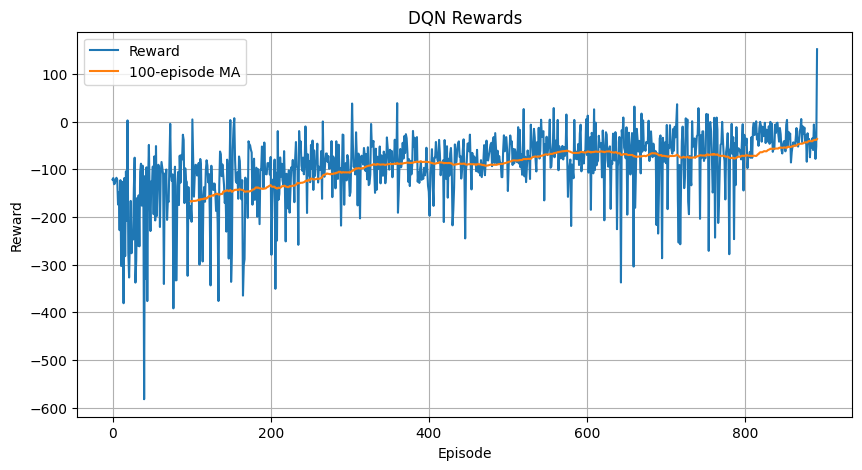

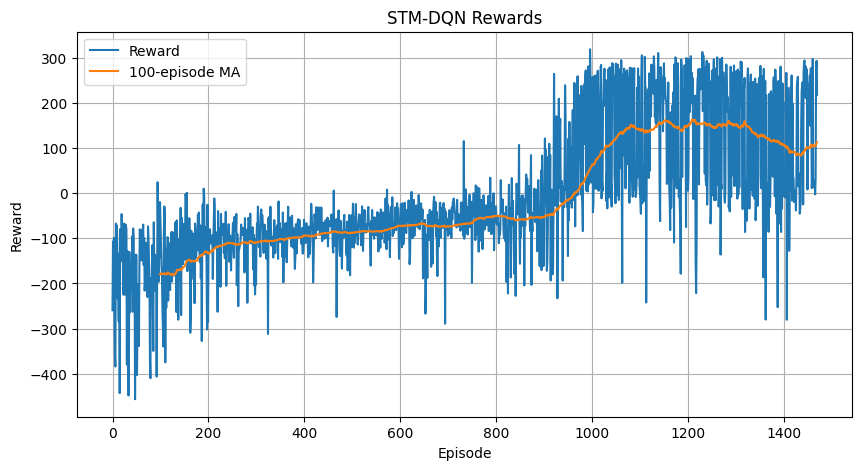

In [ ]:
plot_reward_curve("q_rewards.csv", "Q-Learning Rewards")
plot_reward_curve("dqn_rewards.csv", "DQN Rewards")
plot_reward_curve("stm_dqn_rewards.csv", "STM-DQN Rewards")

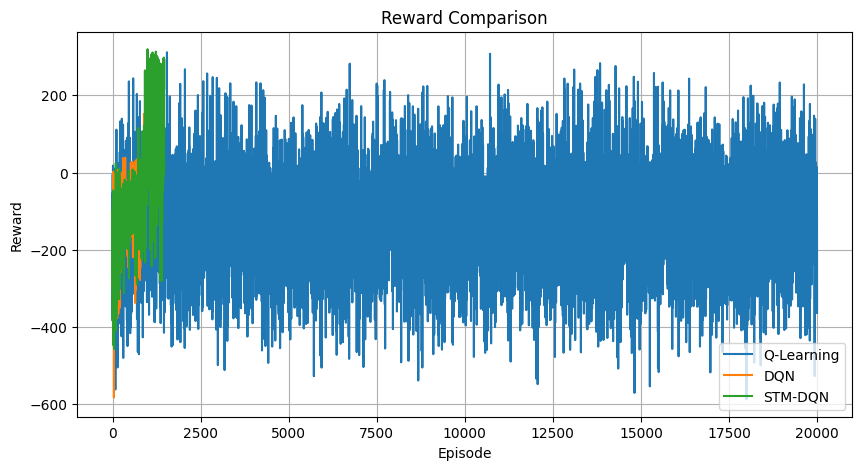

In [ ]:
def plot_combined_rewards():
    q = pd.read_csv(f"{LOGS_DIR}/q_rewards.csv")['reward']
    dqn = pd.read_csv(f"{LOGS_DIR}/dqn_rewards.csv")['reward']
    stm = pd.read_csv(f"{LOGS_DIR}/stm_dqn_rewards.csv")['reward']

    plt.figure(figsize=(10,5))
    plt.plot(q, label="Q-Learning")
    plt.plot(dqn, label="DQN")
    plt.plot(stm, label="STM-DQN")

    plt.title("Reward Comparison")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_combined_rewards()

In [ ]:
def plot_loss_curve(filename, title):
    df = pd.read_csv(f"{LOGS_DIR}/{filename}")
    losses = df['loss'].tolist() if 'loss' in df.columns else df[df.columns[0]]

    plt.figure(figsize=(10,5))
    plt.plot(losses)
    plt.title(title)
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

# If you saved loss logs, use:
# plot_loss_curve("dqn_loss.csv", "DQN Loss")
# plot_loss_curve("stm_dqn_loss.csv", "STM-DQN Loss")

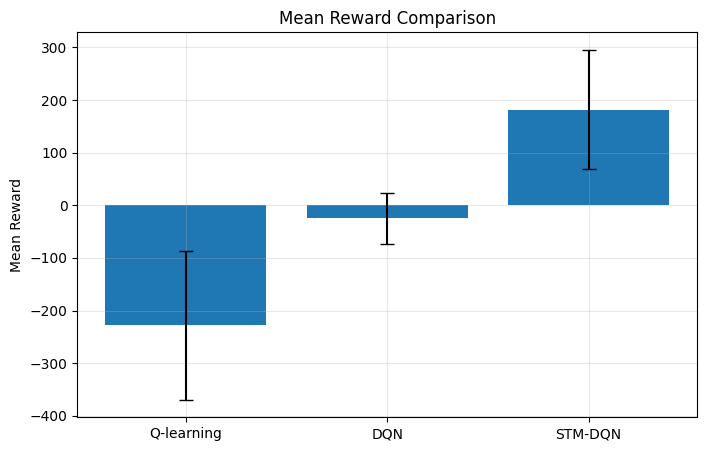

In [ ]:
summary = pd.read_csv("/content/drive/MyDrive/lunar_lander_fullTraining/outputs/model_comparison.csv")

plt.figure(figsize=(8,5))
plt.bar(summary['model'], summary['mean'], yerr=summary['std'], capsize=5)
plt.title("Mean Reward Comparison")
plt.ylabel("Mean Reward")
plt.grid(True, alpha=0.3)
plt.show()

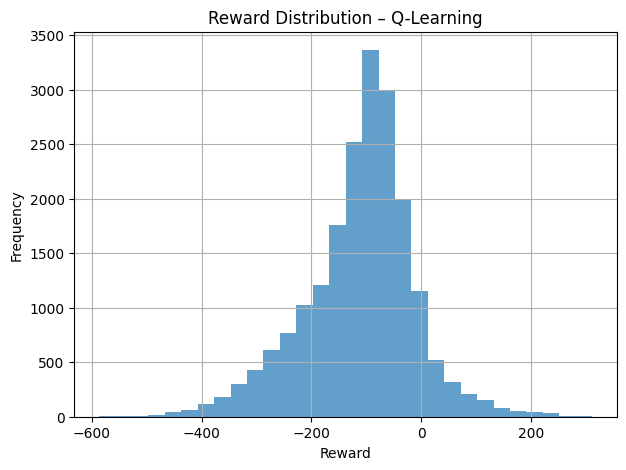

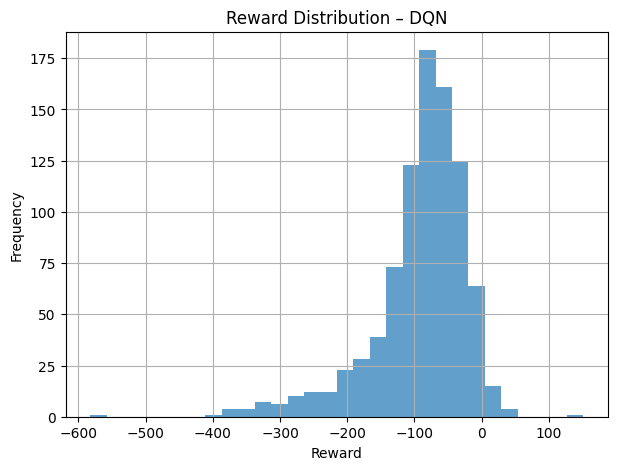

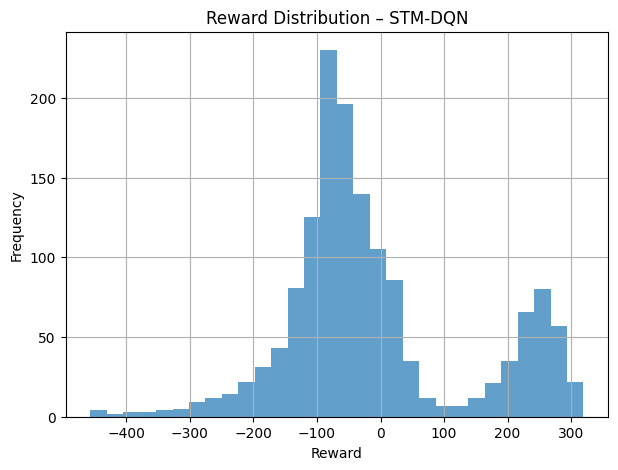

In [ ]:
def plot_reward_hist(file, label):
    rewards = pd.read_csv(f"{LOGS_DIR}/{file}")['reward']

    plt.figure(figsize=(7,5))
    plt.hist(rewards, bins=30, alpha=0.7)
    plt.title(f"Reward Distribution – {label}")
    plt.xlabel("Reward")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

plot_reward_hist("q_rewards.csv","Q-Learning")
plot_reward_hist("dqn_rewards.csv","DQN")
plot_reward_hist("stm_dqn_rewards.csv","STM-DQN")

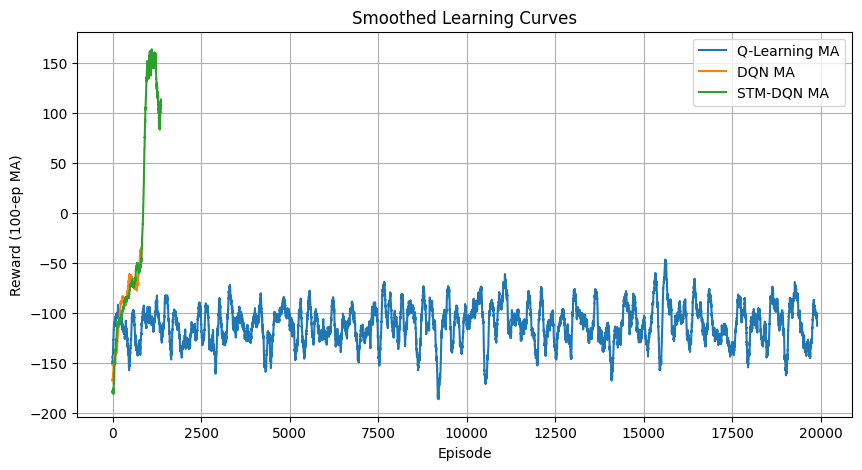

In [ ]:
def moving_avg(x, n=100):
    return np.convolve(x, np.ones(n)/n, mode='valid')

q = moving_avg(pd.read_csv(f"{LOGS_DIR}/q_rewards.csv")['reward'])
dqn = moving_avg(pd.read_csv(f"{LOGS_DIR}/dqn_rewards.csv")['reward'])
stm = moving_avg(pd.read_csv(f"{LOGS_DIR}/stm_dqn_rewards.csv")['reward'])

plt.figure(figsize=(10,5))
plt.plot(q, label="Q-Learning MA")
plt.plot(dqn, label="DQN MA")
plt.plot(stm, label="STM-DQN MA")
plt.title("Smoothed Learning Curves")
plt.xlabel("Episode")
plt.ylabel("Reward (100-ep MA)")
plt.legend()
plt.grid(True)
plt.show()

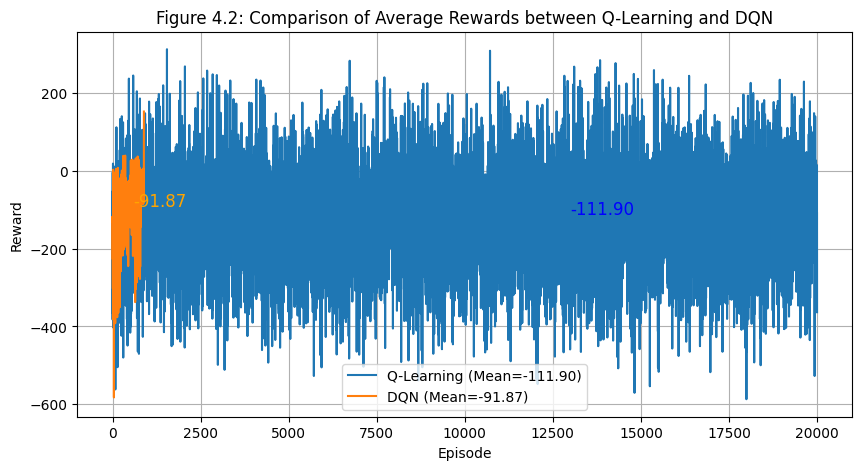

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load rewards
q = pd.read_csv("/content/drive/MyDrive/lunar_lander_fullTraining/outputs/logs/q_rewards.csv")['reward']
dqn = pd.read_csv("/content/drive/MyDrive/lunar_lander_fullTraining/outputs/logs/dqn_rewards.csv")['reward']

# Calculate mean values
q_mean = np.mean(q)
dqn_mean = np.mean(dqn)

plt.figure(figsize=(10,5))
plt.plot(q, label=f"Q-Learning (Mean={q_mean:.2f})")
plt.plot(dqn, label=f"DQN (Mean={dqn_mean:.2f})")

# Add text annotation for mean values
plt.text(len(q)*0.65, q_mean, f"{q_mean:.2f}", color='blue', fontsize=12)
plt.text(len(dqn)*0.65, dqn_mean, f"{dqn_mean:.2f}", color='orange', fontsize=12)

plt.title("Figure 4.2: Comparison of Average Rewards between Q-Learning and DQN")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.show()

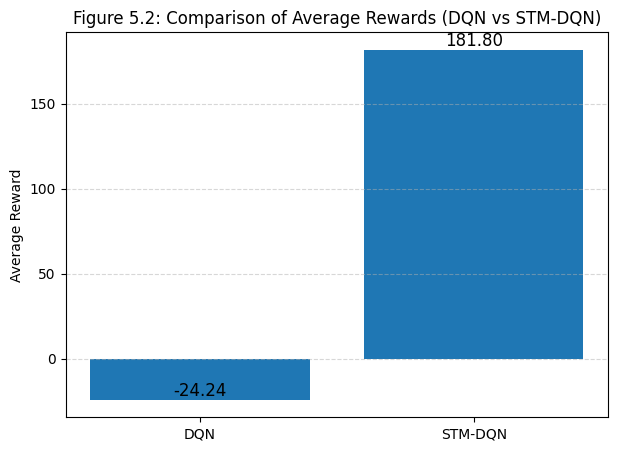

In [ ]:
import matplotlib.pyplot as plt

# Mean rewards (replace with your exact values if needed)
dqn_mean = -24.24
stm_mean = 181.80

models = ['DQN', 'STM-DQN']
means = [dqn_mean, stm_mean]

plt.figure(figsize=(7,5))
bars = plt.bar(models, means)

# Write values above bars
for bar, value in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{value:.2f}', ha='center', va='bottom', fontsize=12)

plt.title("Figure 5.2: Comparison of Average Rewards (DQN vs STM-DQN)")
plt.ylabel("Average Reward")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

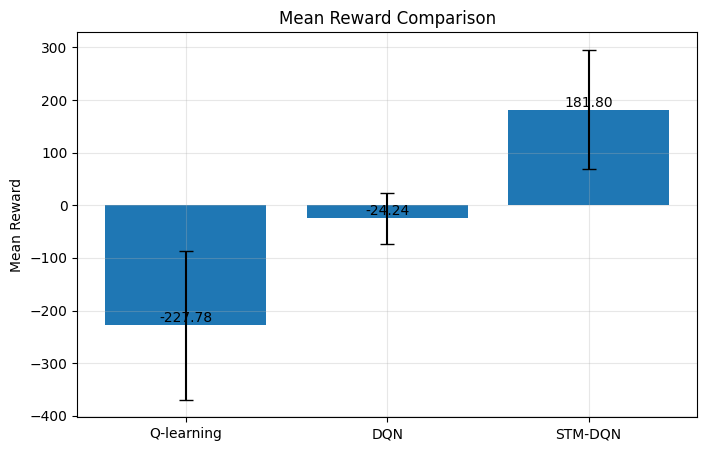

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("/content/drive/MyDrive/lunar_lander_fullTraining/outputs/model_comparison.csv")

plt.figure(figsize=(8,5))
bars = plt.bar(summary['model'], summary['mean'], yerr=summary['std'], capsize=5)

# Print values on the bars
for bar, mean, std in zip(bars, summary['mean'], summary['std']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{mean:.2f}",
             ha='center', va='bottom', fontsize=10)

plt.title("Mean Reward Comparison")
plt.ylabel("Mean Reward")
plt.grid(True, alpha=0.3)
plt.show()


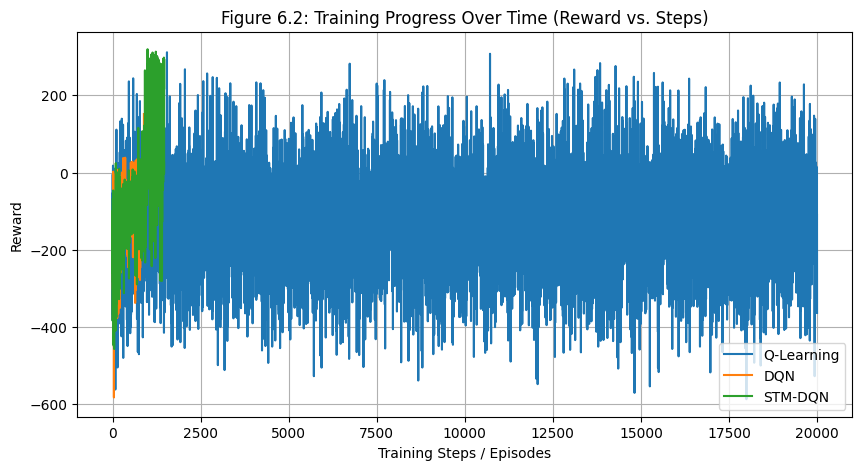

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load reward logs
q = pd.read_csv("/content/drive/MyDrive/lunar_lander_fullTraining/outputs/logs/q_rewards.csv")['reward']
dqn = pd.read_csv("/content/drive/MyDrive/lunar_lander_fullTraining/outputs/logs/dqn_rewards.csv")['reward']
stm = pd.read_csv("/content/drive/MyDrive/lunar_lander_fullTraining/outputs/logs/stm_dqn_rewards.csv")['reward']

# Plot
plt.figure(figsize=(10,5))
plt.plot(q, label="Q-Learning")
plt.plot(dqn, label="DQN")
plt.plot(stm, label="STM-DQN")

plt.title("Figure 6.2: Training Progress Over Time (Reward vs. Steps)")
plt.xlabel("Training Steps / Episodes")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.show()